
First 5 rows of the California Housing dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Selected features (X) shape: (20640, 2)
Target (y) shape: (20640,)

Learned Regression Equation:
MedHouseVal = 0.59 + (0.43 * MedInc) + (-0.04 * AveRooms)


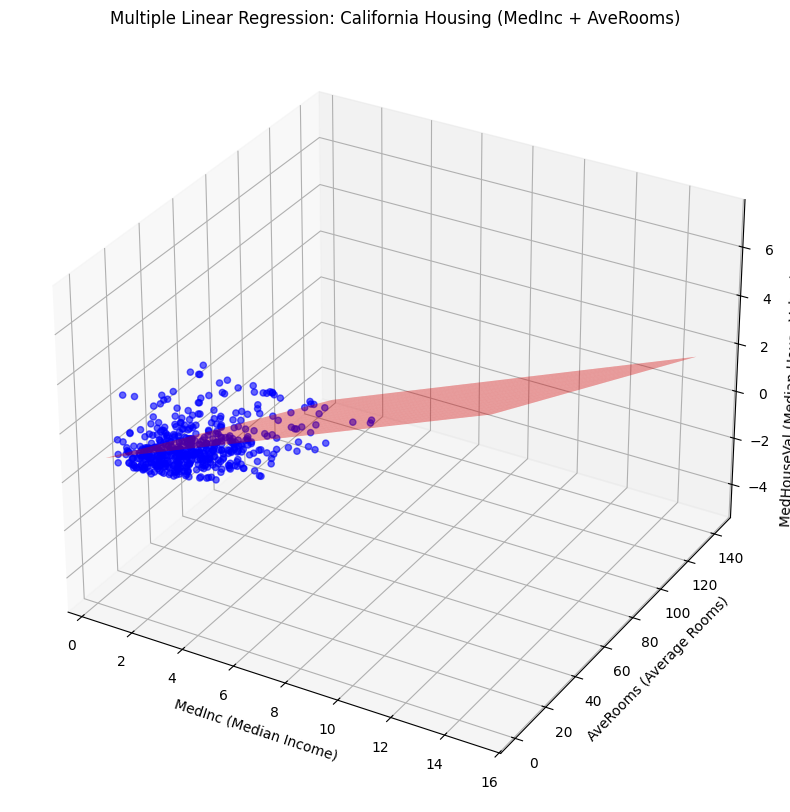


Example Predictions:
For MedInc=3, AveRooms=4 -> Predicted MedHouseVal = $174500.51
For MedInc=6, AveRooms=6 -> Predicted MedHouseVal = $297127.29
For MedInc=9, AveRooms=8 -> Predicted MedHouseVal = $419754.07


In [2]:
# Nguyễn Hoàng Tùng

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

# 1. Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("\nFirst 5 rows of the California Housing dataset:")
print(df.head())

# 2. Select features (e.g., MedInc = median income, AveRooms = average rooms per household)
X = pd.DataFrame(np.c_[df["MedInc"], df["AveRooms"]], columns=["MedInc", "AveRooms"])
y = df["MedHouseVal"]

print(f"\nSelected features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# 3. Train Linear Regression model
model = LinearRegression()
model.fit(X, y)

# 4. Print regression equation
intercept = model.intercept_
coef_MedInc, coef_AveRooms = model.coef_

print("\nLearned Regression Equation:")
print(f"MedHouseVal = {intercept:.2f} + ({coef_MedInc:.2f} * MedInc) + ({coef_AveRooms:.2f} * AveRooms)")

# 5. Visualization (3D regression plane)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot of actual data (sampled for clarity)
sample_idx = np.random.choice(len(X), 500, replace=False)
ax.scatter(X["MedInc"].iloc[sample_idx], X["AveRooms"].iloc[sample_idx], y.iloc[sample_idx],
           color="blue", label="Actual Data", s=20, alpha=0.6)

# Create meshgrid for regression plane
x_surf = np.linspace(X["MedInc"].min(), X["MedInc"].max(), 50)
y_surf = np.linspace(X["AveRooms"].min(), X["AveRooms"].max(), 50)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)
z_surf = model.intercept_ + model.coef_[0]*x_surf + model.coef_[1]*y_surf

# Plot regression plane
ax.plot_surface(x_surf, y_surf, z_surf, color="red", alpha=0.4)

# Labels
ax.set_xlabel("MedInc (Median Income)")
ax.set_ylabel("AveRooms (Average Rooms)")
ax.set_zlabel("MedHouseVal (Median House Value in $100,000s)")
ax.set_title("Multiple Linear Regression: California Housing (MedInc + AveRooms)")

plt.show()

# 6. Example predictions
print("\nExample Predictions:")
new_data = pd.DataFrame({
    "MedInc": [3, 6, 9],
    "AveRooms": [4, 6, 8]
})
predictions = model.predict(new_data)

for i in range(len(new_data)):
    print(f"For MedInc={new_data['MedInc'][i]}, AveRooms={new_data['AveRooms'][i]} "
          f"-> Predicted MedHouseVal = ${predictions[i]*100000:.2f}")
